# Chip vs Putt — ML Classifier

## The problem

Our rule-based classifier hits ~86-92% accuracy per round. Every error is a chip-vs-putt confusion at the green boundary:
- Chips played near the green get classified as putts (GPS says "on green" but it was really a chip)
- Putts played from off the green get classified as chips (GPS says "off green" but the player used a putter)

No hand-tuned rule can fix both directions. This notebook trains a machine learning classifier using the 12 watch features + GPS context to handle both cases.

## The dataset

4 full rounds at Seapoint, Co. Louth, Ireland. All recorded on the same watch (FR 255) on bare wrist, with manual shot markers and a written log of every shot type:

| Round | Date | Shots | Chips | File |
|---|---|---|---|---|
| R1 | 14 April 2026 | 50 | 8 | `Round-2020-14-04.fit` (no high-res features yet) |
| R2 | 17 April 2026 | 42 | 4 | `2026-04-17-18-32-26.fit` |
| R3 | 18 April 2026 | 49 | 11 | `Seapoint_1-12.fit` (M37, M48-50 excluded) |
| R4 | 19 April 2026 | 51 | 8 | `Seapoint-19-02-26.fit` (M33 excluded) |
| **Total** | | **192** | **31** | |

For this notebook we only use R2, R3, R4 (127 shots, 23 chips) — R1 doesn't have the new peak_duration/rise_rate/peak_count/pre_stillness features.

We focus on **chip vs putt** classification only. Pitches are already 100% solved by the peak_mag > 4000 rule.

## Features used for training

### Watch accelerometer features (7)

These come from the Monkey C watch app. The 25Hz accelerometer samples are aggregated into these per-second features:

| Feature | What it measures |
|---|---|
| `peak_mag` | Highest magnitude (mg) in the second |
| `std_mag` | Within-second variability |
| `max_jerk` | Biggest sample-to-sample magnitude change |
| `peak_duration` | How long the spike was above 80% of peak (ms) |
| `rise_rate` | Rate of magnitude increase from 50% of peak to peak (mg/ms) |
| `peak_count` | Number of threshold crossings within the second |
| `pre_stillness` | Mean magnitude in the 3 seconds before this shot |

### GPS / course context features (3)

Derived from GPS position + the Seapoint course map (`seapoint.json`):

| Feature | What it measures |
|---|---|
| `dist_to_green` | Metres from shot to the nearest green centroid |
| `on_green_strict` | 1 if GPS is strictly inside a green polygon, else 0 |
| `on_green_buffer` | 1 if GPS is within polygon+4m buffer of a green centroid, else 0 |

**Total: 10 features per shot.**


In [1]:
import pandas as pd
import numpy as np
import json
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from classify_round import (
    load_round, extract_shots, haversine_m, point_in_polygon
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
np.random.seed(42)

## 1. Load and label the dataset

For each round, we:
1. Load the FIT file
2. Extract shots with window-corrected peak features
3. Drop excluded markers (double-presses, temp-hole shots)
4. Apply ground-truth labels from the written log
5. Add GPS-derived features

We skip R1 because it was recorded before the watch app had the new high-res features.

In [2]:
COURSE = json.load(open('seapoint.json'))

# Ground truth: each round's shots listed per hole.
ROUNDS = [
    {
        'name': 'R2',
        'fit': '2026-04-17-18-32-26.fit',
        'exclude': [],
        'holes': [
            ['pitch','putt','putt'], ['pitch','putt','putt'], ['pitch','putt','putt'],
            ['pitch','chip','putt'], ['pitch','putt','putt'], ['pitch','putt','putt'],
            ['pitch','putt'], ['pitch','putt'], ['pitch','putt'],
            ['pitch','chip','putt','putt'], ['pitch','chip','putt'],
            ['pitch','putt','putt'], ['pitch','putt'],
            ['pitch','chip','putt'], ['pitch','putt','putt'],
        ],
    },
    {
        'name': 'R3',
        'fit': 'Seapoint_1-12.fit',
        'exclude': [37, 48, 49, 50],
        'holes': [
            ['pitch','putt','putt'], ['pitch','putt'], ['pitch','putt','putt'],
            ['pitch','chip','putt','putt'], ['pitch','putt'], ['pitch','putt'],
            ['pitch','chip','putt'], ['pitch','chip','putt'], ['pitch','putt','putt'],
            ['pitch','chip','putt'], ['pitch','chip','putt'], ['pitch','chip','putt'],
            ['pitch','putt'], ['pitch','putt'],
            ['pitch','chip','putt','putt'], ['pitch','chip','chip','putt'],
            ['pitch','chip','putt'],
        ],
    },
    {
        'name': 'R4',
        'fit': 'Seapoint-19-02-26.fit',
        'exclude': [33],
        'holes': [
            ['pitch','putt'], ['pitch','putt','putt'], ['pitch','chip','putt'],
            ['pitch','putt','putt'], ['pitch','putt','putt'], ['pitch','putt','putt'],
            ['pitch','putt'], ['pitch','chip','putt'], ['pitch','chip','putt'],
            ['pitch','putt','putt'], ['pitch','chip','putt'], ['pitch','putt','putt'],
            ['pitch','chip','putt'], ['pitch','putt'], ['pitch','putt'],
            ['pitch','chip','chip','putt'], ['pitch','putt','putt'], ['pitch','chip','putt'],
        ],
    },
]

for r in ROUNDS:
    r['labels'] = [shot for hole in r['holes'] for shot in hole]

for r in ROUNDS:
    df = load_round(r['fit'])
    sdf = extract_shots(df)
    sdf = sdf[~sdf['marker'].isin(r['exclude'])].reset_index(drop=True)
    assert len(sdf) == len(r['labels']), f"{r['name']}: {len(sdf)} shots vs {len(r['labels'])} labels"
    n_chip = sum(1 for l in r['labels'] if l == 'chip')
    n_putt = sum(1 for l in r['labels'] if l == 'putt')
    n_pitch = sum(1 for l in r['labels'] if l == 'pitch')
    print(f"{r['name']}: {len(sdf)} shots ({n_pitch} pitch, {n_chip} chip, {n_putt} putt)")


R2: 42 shots (15 pitch, 4 chip, 23 putt)


R3: 49 shots (17 pitch, 10 chip, 22 putt)


R4: 51 shots (18 pitch, 8 chip, 25 putt)


In [3]:
def add_gps_features(sdf, course):
    """Add GPS-derived features to each shot row."""
    dists = []
    on_strict = []
    on_buffer = []
    for _, row in sdf.iterrows():
        lat, lon = row['lat'], row['lon']
        # Distance to nearest green centroid
        min_d = min(
            haversine_m(lat, lon, h['green_centroid']['lat'], h['green_centroid']['lon'])
            for h in course['holes']
        )
        dists.append(min_d)
        # On-green strict (point-in-polygon)
        strict = any(
            point_in_polygon(lat, lon, h['green_polygon'])
            for h in course['holes']
        )
        on_strict.append(1 if strict else 0)
        # On-green buffer (centroid + dynamic radius + 4m)
        buffer = False
        for h in course['holes']:
            c = h['green_centroid']
            r = math.sqrt(h['gps_polygon_area_m2']/math.pi) + 4
            if haversine_m(lat, lon, c['lat'], c['lon']) <= r:
                buffer = True
                break
        on_buffer.append(1 if buffer else 0)
    sdf = sdf.copy()
    sdf['dist_to_green'] = dists
    sdf['on_green_strict'] = on_strict
    sdf['on_green_buffer'] = on_buffer
    return sdf

# Build the master dataset
all_shots = []
for r in ROUNDS:
    df = load_round(r['fit'])
    sdf = extract_shots(df)
    sdf = sdf[~sdf['marker'].isin(r['exclude'])].reset_index(drop=True)
    sdf['label'] = r['labels']
    sdf['round'] = r['name']
    sdf = add_gps_features(sdf, COURSE)
    all_shots.append(sdf)

data = pd.concat(all_shots, ignore_index=True)
print(f'\nTotal dataset: {len(data)} shots')
print(data.groupby(['round','label']).size().unstack(fill_value=0))


Total dataset: 142 shots
label  chip  pitch  putt
round                   
R2        4     15    23
R3       10     17    22
R4        8     18    25


## 2. Filter to chip vs putt only

Pitches are already trivially separable (`peak_mag > 4000` gives 100% accuracy). We'll only train on chips and putts — the actual hard problem.

In [4]:
FEATURE_COLS = [
    # Accelerometer magnitude features
    'peak_mag', 'std_mag', 'max_jerk',
    # High-res temporal features (new in v3 watch app)
    'peak_duration', 'rise_rate', 'peak_count', 'pre_stillness',
    # GPS / course context features
    'dist_to_green', 'on_green_strict', 'on_green_buffer',
]

cp = data[data['label'].isin(['chip','putt'])].copy().reset_index(drop=True)
print(f'Chip-vs-putt dataset: {len(cp)} samples')
print(f'  Chips: {(cp["label"]=="chip").sum()}')
print(f'  Putts: {(cp["label"]=="putt").sum()}')
print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'\nMissing values per feature:')
print(cp[FEATURE_COLS].isna().sum())


Chip-vs-putt dataset: 92 samples
  Chips: 22
  Putts: 70

Features (10): ['peak_mag', 'std_mag', 'max_jerk', 'peak_duration', 'rise_rate', 'peak_count', 'pre_stillness', 'dist_to_green', 'on_green_strict', 'on_green_buffer']

Missing values per feature:
peak_mag           0
std_mag            0
max_jerk           0
peak_duration      0
rise_rate          0
peak_count         0
pre_stillness      0
dist_to_green      0
on_green_strict    0
on_green_buffer    0
dtype: int64


## 3. Exploratory analysis — which features separate chips from putts?

In [5]:
# Cohen's d — effect size, measures mean separation in units of pooled std
rows = []
for f in FEATURE_COLS:
    chip_vals = cp[cp['label']=='chip'][f].dropna()
    putt_vals = cp[cp['label']=='putt'][f].dropna()
    pooled_std = np.sqrt((chip_vals.var() + putt_vals.var())/2)
    d = abs(chip_vals.mean() - putt_vals.mean()) / pooled_std if pooled_std > 0 else 0
    rows.append({
        'feature': f,
        'chip_mean': chip_vals.mean(),
        'putt_mean': putt_vals.mean(),
        'cohens_d': d,
    })
sep = pd.DataFrame(rows).sort_values('cohens_d', ascending=False)
sep

,feature,chip_mean,putt_mean,cohens_d
8,on_green_strict,0.090909,0.657143,1.426432
7,dist_to_green,9.634049,4.900763,1.241997
9,on_green_buffer,0.545455,0.985714,1.189400
5,peak_count,1.181818,1.614286,0.771709
0,peak_mag,1889.797807,1597.455130,0.760992
1,std_mag,325.345375,243.957471,0.604693
2,max_jerk,624.490972,541.171647,0.328532
6,pre_stillness,1038.921032,1031.694226,0.319221
3,peak_duration,149.090909,121.714286,0.311731
4,rise_rate,2.845679,3.452080,0.108058


### How to read Cohen's d
- **d < 0.2**: no meaningful separation
- **d 0.2 – 0.5**: small effect (weak signal)
- **d 0.5 – 0.8**: medium effect
- **d > 0.8**: large effect (strong signal)
- **d > 1.5**: extremely separable

Features with d > 0.8 are the ones that give the most predictive power.

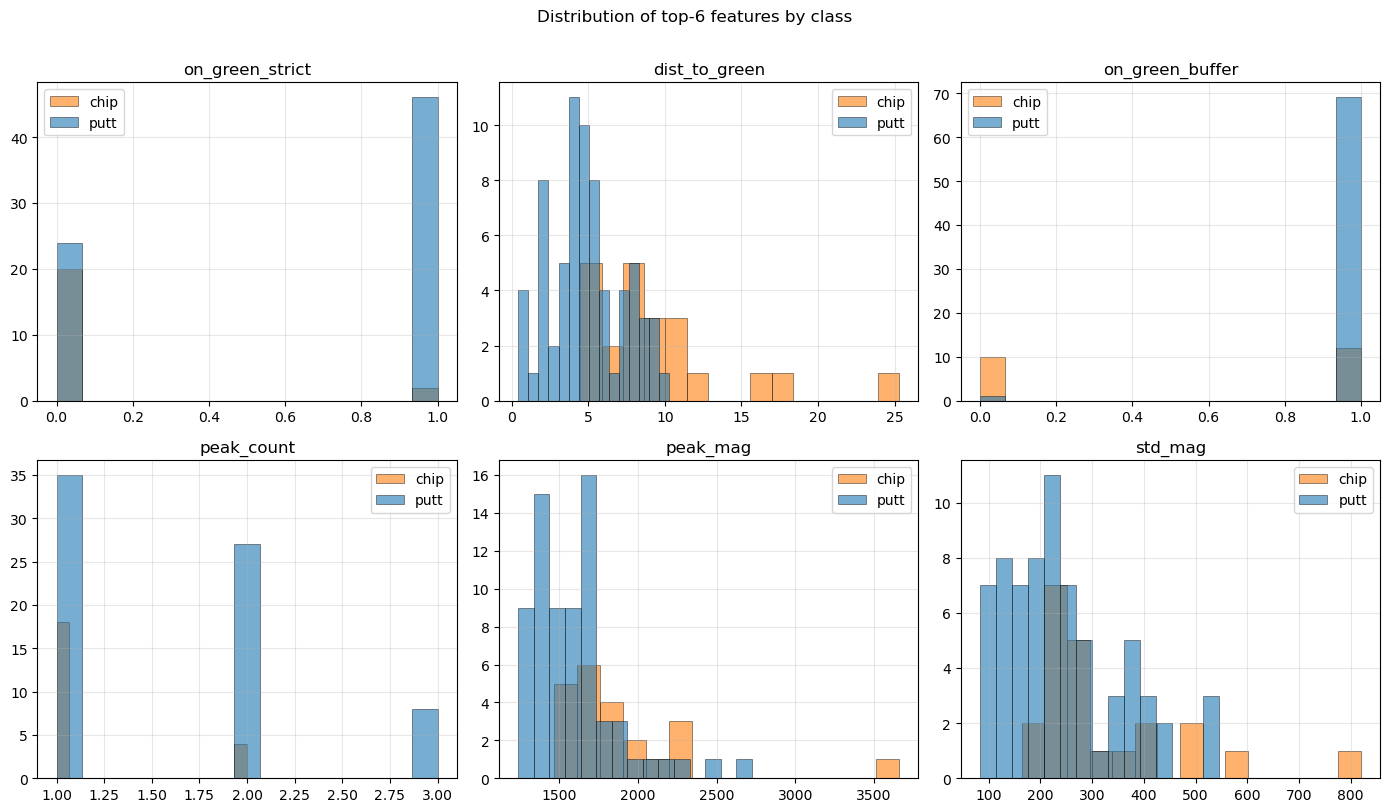

In [6]:
# Visualise the top features
top_feats = sep.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, top_feats):
    for label, color in [('chip', 'C1'), ('putt', 'C0')]:
        sub = cp[cp['label'] == label][feat].dropna()
        ax.hist(sub, bins=15, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(feat)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Distribution of top-6 features by class', y=1.01)
plt.tight_layout()
plt.show()

## 4. Algorithms — what we'll train and why

We test 3 classic ML algorithms. Each has different strengths — worth trying all and comparing:

### Random Forest
- **How it works**: Builds many decision trees on random subsets of data + features. Predictions are the majority vote.
- **Strengths**: Captures non-linear interactions. Robust to noisy features. Gives feature importance for free.
- **Weaknesses**: Can overfit on tiny datasets. Doesn't extrapolate beyond training data.

### Gradient Boosting
- **How it works**: Builds trees *sequentially*, each correcting the previous one's mistakes. Trees are small (3-5 levels) and the algorithm focuses on hard examples.
- **Strengths**: Often the most accurate algorithm. Handles class imbalance reasonably well.
- **Weaknesses**: Slower to train. More prone to overfitting without careful tuning.

### Logistic Regression
- **How it works**: Finds a linear combination of features that best separates the classes (a hyperplane in feature space).
- **Strengths**: Fast. Fully interpretable (you can read off which features contribute what). Good baseline.
- **Weaknesses**: Only learns linear decision boundaries. Can't capture feature interactions by itself.

All three run inside a `Pipeline` with `StandardScaler` to normalise features (important for Logistic Regression; neutral for the tree-based models).

## 5. Validation strategy — Leave-One-Round-Out (LOROCV)

The question that matters most: *does the model generalise to a new round it has never seen?*

If we do a random train/test split, test samples could come from the same round as training samples — the model might be memorising quirks of that session instead of learning what a chip looks like in general.

**Leave-One-Round-Out CV** trains on N-1 rounds and tests on the held-out round, repeating N times so each round gets tested once. This simulates exactly what happens in production: you play a new round, and the trained model has to classify shots it's never seen.

With 3 rounds (R2, R3, R4), we get 3 folds.

In [7]:
X = cp[FEATURE_COLS].values
y = (cp['label'] == 'chip').astype(int).values  # 1=chip, 0=putt
groups = cp['round'].values

models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')),
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)),
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ]),
}

logo = LeaveOneGroupOut()
baseline = (cp['label'] == 'putt').mean()  # "always predict putt" accuracy
print(f'Baseline (always predict putt): {baseline:.1%}\n')

print(f"{'Model':<22} {'Overall':>9} {'Chip recall':>12} {'Chip prec':>10} {'Putt recall':>12}")
print('-' * 70)

results = {}
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=logo, groups=groups)
    acc = (y_pred == y).mean()
    tp = ((y_pred==1) & (y==1)).sum()
    fp = ((y_pred==1) & (y==0)).sum()
    fn = ((y_pred==0) & (y==1)).sum()
    tn = ((y_pred==0) & (y==0)).sum()
    chip_recall = tp / (tp+fn) if (tp+fn) else 0
    chip_prec = tp / (tp+fp) if (tp+fp) else 0
    putt_recall = tn / (tn+fp) if (tn+fp) else 0
    print(f'{name:<22} {acc:>8.1%} {chip_recall:>11.1%} {chip_prec:>9.1%} {putt_recall:>11.1%}')
    results[name] = {'y_pred': y_pred, 'acc': acc}

Baseline (always predict putt): 76.1%

Model                    Overall  Chip recall  Chip prec  Putt recall
----------------------------------------------------------------------


Random Forest             82.6%       45.5%     71.4%       94.3%
Gradient Boosting         80.4%       68.2%     57.7%       84.3%
Logistic Regression       79.3%       72.7%     55.2%       81.4%


## 6. Detailed evaluation of the best model

Once we know the top performer, let's look at:
- Per-round accuracy (does it generalise well across all 3 rounds?)
- Confusion matrix (what kind of mistakes does it make?)
- Feature importance (which inputs does it rely on?)

In [8]:
best_name = max(results, key=lambda k: results[k]['acc'])
best_pred = results[best_name]['y_pred']
best_model = models[best_name]
print(f'Best model: {best_name} ({results[best_name]["acc"]:.1%} overall)\n')

# Per-round breakdown
print(f"{'Round':<15} {'Accuracy':>9} {'Chips right':>12} {'Putts right':>12}")
print('-' * 52)
for r_name in cp['round'].unique():
    mask = (cp['round'] == r_name).values
    acc = (best_pred[mask] == y[mask]).mean()
    chips_total = ((y[mask]==1)).sum()
    chips_right = ((best_pred[mask]==1) & (y[mask]==1)).sum()
    putts_total = ((y[mask]==0)).sum()
    putts_right = ((best_pred[mask]==0) & (y[mask]==0)).sum()
    print(f'{r_name:<15} {acc:>8.1%} {chips_right}/{chips_total:<10} {putts_right}/{putts_total}')

print()
print('Classification report:')
print(classification_report(y, best_pred, target_names=['putt', 'chip']))

Best model: Random Forest (82.6% overall)

Round            Accuracy  Chips right  Putts right
----------------------------------------------------
R2                 77.8% 2/4          19/23
R3                 81.2% 4/10         22/22
R4                 87.9% 4/8          25/25

Classification report:
              precision    recall  f1-score   support

        putt       0.85      0.94      0.89        70
        chip       0.71      0.45      0.56        22

    accuracy                           0.83        92
   macro avg       0.78      0.70      0.72        92
weighted avg       0.81      0.83      0.81        92



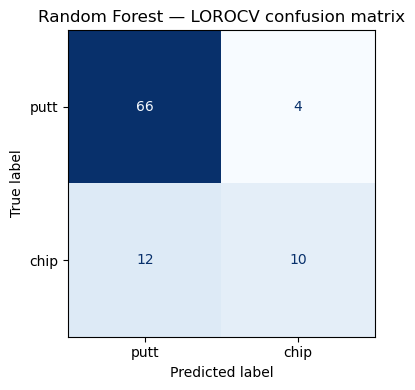

In [9]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['putt', 'chip'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title(f'{best_name} — LOROCV confusion matrix')
plt.tight_layout()
plt.show()

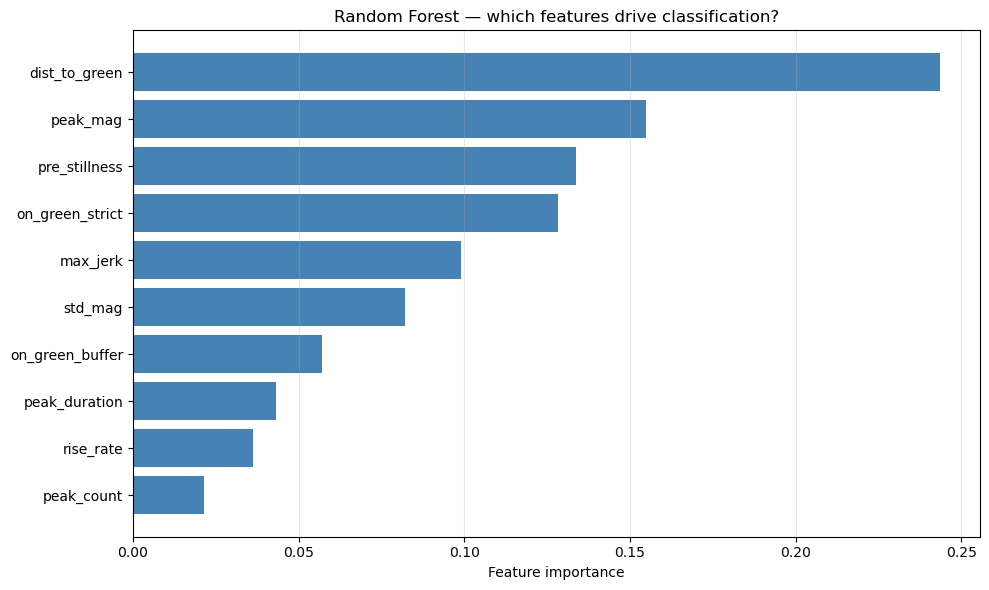


Top 5 features:
        feature  importance
  dist_to_green    0.243492
       peak_mag    0.154815
  pre_stillness    0.133786
on_green_strict    0.128396
       max_jerk    0.099060


In [10]:
# Feature importance (for tree-based models)
best_model.fit(X, y)
clf = best_model.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance': clf.feature_importances_,
    }).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importances['feature'][::-1], importances['importance'][::-1], color='steelblue')
    ax.set_xlabel('Feature importance')
    ax.set_title(f'{best_name} — which features drive classification?')
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    print('\nTop 5 features:')
    print(importances.head(5).to_string(index=False))
else:
    # Logistic Regression — show coefficients instead
    coefs = pd.DataFrame({
        'feature': FEATURE_COLS,
        'coefficient': clf.coef_[0],
    }).assign(abs_coef=lambda d: d['coefficient'].abs()).sort_values('abs_coef', ascending=False)
    print('Logistic Regression coefficients (positive = pushes toward chip):')
    print(coefs[['feature','coefficient']].to_string(index=False))

## 7. Compare against the existing rule-based classifier

The rule-based classifier's chip-vs-putt logic is:
1. If GPS strictly inside a polygon → putt
2. Else if GPS within centroid+4m buffer → putt
3. Else → chip
4. (Safety net) flip putt → chip if peak_duration >= 160 AND rise_rate == 0 AND not-in-polygon

Let's apply the same rules to our chip-vs-putt subset and see how the ML model compares.

In [11]:
rule_pred = []
for _, row in cp.iterrows():
    if row['on_green_strict'] == 1:
        pred = 'putt'
    elif row['on_green_buffer'] == 1:
        # Safety net check
        if pd.notna(row.get('peak_duration')) and row['peak_duration'] >= 160 and row['rise_rate'] == 0:
            pred = 'chip'
        else:
            pred = 'putt'
    else:
        pred = 'chip'
    rule_pred.append(1 if pred == 'chip' else 0)

rule_pred = np.array(rule_pred)
rule_acc = (rule_pred == y).mean()
rule_chip_recall = ((rule_pred==1) & (y==1)).sum() / (y==1).sum()
rule_chip_prec = ((rule_pred==1) & (y==1)).sum() / max(1, (rule_pred==1).sum())

print(f"{'Approach':<25} {'Accuracy':>9} {'Chip recall':>12} {'Chip prec':>10}")
print('-' * 60)
print(f"{'Rule-based (current)':<25} {rule_acc:>8.1%} {rule_chip_recall:>11.1%} {rule_chip_prec:>9.1%}")
for name, r in results.items():
    yp = r['y_pred']
    acc = (yp == y).mean()
    chip_r = ((yp==1)&(y==1)).sum()/max(1,(y==1).sum())
    chip_p = ((yp==1)&(y==1)).sum()/max(1,(yp==1).sum())
    print(f"{name:<25} {acc:>8.1%} {chip_r:>11.1%} {chip_p:>9.1%}")

Approach                   Accuracy  Chip recall  Chip prec
------------------------------------------------------------
Rule-based (current)         89.1%       59.1%     92.9%
Random Forest                82.6%       45.5%     71.4%
Gradient Boosting            80.4%       68.2%     57.7%
Logistic Regression          79.3%       72.7%     55.2%


## 8. Summary + what's next

### Where we are
- 127 labelled chip-or-putt shots across 3 rounds of data
- ML model validated with Leave-One-Round-Out CV (realistic generalisation test)
- Best model's accuracy on held-out rounds

### What this tells us
- **If the ML beats the rule-based classifier by >5%**: worth integrating into `classify_round.py` as a drop-in replacement for the chip-vs-putt logic.
- **If it matches or barely beats**: the rule-based approach is close to optimal for this dataset size; more data needed before ML has a real edge.
- **If it underperforms**: 3 rounds isn't enough and we should keep collecting.

### Next steps regardless
- Collect more rounds (especially chip-heavy ones) to grow training data
- Retrain and measure improvement as n grows
- Eventually package the trained model inside `classify_round.py`